# ASX Coverage Toolkit — Showcase Notebook

An end-to-end walkthrough of the pipeline that turns the raw list of **~1,979 ASX-listed entities** into a fully enriched, analysis-ready research database.

**Pipeline:** load source universe → automatically fetch live market data (yfinance) → enrich & classify → analyse → export to Excel.

*Part of the [asx-coverage-toolkit](..) repository. General information only — not financial advice.*

## 0 · Setup

Add the project root to the path so the pipeline modules under `src/` are importable, then load the data-science stack.

In [1]:
%matplotlib inline
import re
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Make the project modules importable whether we run from notebooks/ or the repo root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA = ROOT / "data"
NAVY, GREEN, BLUE, GOLD = "#1B3A6B", "#1B5E20", "#1565C0", "#C9A84C"
print("Project root:", ROOT)

C:\Users\henry\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Project root: C:\Users\henry\Desktop\career\Resumes\github\asx_coverage_toolkit


## 1 · The source universe

The pipeline starts from `data/ASX_Entities_Enriched.csv` — every ASX-listed entity with its GICS classification. Only a handful of rows arrive with any market data; everything else is filled in downstream.

In [2]:
source = pd.read_csv(DATA / "ASX_Entities_Enriched.csv")
print(f"{len(source):,} entities x {source.shape[1]} source columns")
source.head()

1,979 entities x 7 source columns


,Company name,ASX code,GICS industry group,GICS Industry (Sub-Level),Share Price (AUD),Market Cap (Billion AUD),Outstanding Shares (Billion)
0,COMMONWEALTH BANK OF AUSTRALIA.,CBA,Banks,Banks,172.80,289.17,1.673
1,BHP GROUP LIMITED,BHP,Materials,Chemicals; Construction Materials; Metals & Mi...,51.23,260.32,5.081
2,WESTPAC BANKING CORPORATION,WBC,Banks,Banks,39.85,136.30,3.420
3,NATIONAL AUSTRALIA BANK LIMITED,NAB,Banks,Banks,41.80,128.23,3.068
4,ANZ GROUP HOLDINGS LIMITED,ANZ,Banks,Banks,36.63,110.41,3.014


In [3]:
have_mc = source["Market Cap (Billion AUD)"].notna().sum()
print(f"Rows arriving with market cap in the raw source: {have_mc} / {len(source):,}")
print("=> the other", f"{len(source) - have_mc:,}", "rows depend entirely on the pipeline.")

Rows arriving with market cap in the raw source: 30 / 1,979
=> the other 1,949 rows depend entirely on the pipeline.


## 2 · Automated data gathering (yfinance)

`get_live_data()` converts each ASX code to its Yahoo Finance symbol (`CBA` → `CBA.AX`), pulls ~30 fields per ticker, and caches the result to `data/yfinance_cache.json` with a 24-hour TTL. The full universe ships pre-cached, so this loads instantly offline; with a stale cache the same call fetches live.

In [4]:
from src.fetch_live import load_cache

cache = load_cache(DATA / "yfinance_cache.json")
print(f"Live snapshot cached for {len(cache):,} tickers")

# The raw depth of what we gather, for one well-known name:
sample = cache.get("CBA", {})
for k in ["longName", "currentPrice", "marketCap", "trailingPE", "priceToBook",
          "dividendYield", "fiftyTwoWeekHigh", "fiftyTwoWeekLow",
          "recommendationKey", "numberOfAnalystOpinions", "targetMeanPrice",
          "averageVolume"]:
    if k in sample:
        print(f"  {k:26s} {sample[k]}")

Live snapshot cached for 1,844 tickers
  longName                   Commonwealth Bank of Australia
  currentPrice               161.89
  marketCap                  270700118016
  trailingPE                 26.027332
  priceToBook                3.505023
  dividendYield              3.1
  fiftyTwoWeekHigh           192.0
  fiftyTwoWeekLow            146.98
  recommendationKey          sell
  numberOfAnalystOpinions    14
  targetMeanPrice            122.77947
  averageVolume              2194446


## 3 · Enrichment

`enrich()` merges three sources by **per-field priority — Research Data → Live Data → Sector default** — so live values fill gaps for unresearched names but never overwrite curated fundamentals. It then derives entity type, market-cap category, the four GICS tiers, index membership and data-quality notes, producing the 44-column database.

In [5]:
from src.enrich import enrich

df = enrich(source_csv=DATA / "ASX_Entities_Enriched.csv", live_data=cache)
print(f"Enriched: {len(df):,} rows x {df.shape[1]} columns")
df.head()

Enriched: 1,979 rows x 44 columns


,Company,ASX Ticker,Entity Type,Market Cap Category,GICS Sector,GICS Industry Group,GICS Industry,GICS Sub-Industry,Market Cap (AUD),Market Cap Data Date,Share Price (AUD),Shares Outstanding,"Revenue (AUD, Latest Annual)",Net Profit/Loss (AUD),Dividend Yield,Franking Level,P/E Ratio,Price/Book,Beta (vs ASX 200),Return on Equity (ROE),Debt/Equity Ratio,Reporting Currency,Fiscal Year End,CEO / MD,Website,Year Founded,Business Description,HQ State / Territory,Primary Country of Operations,Domicile,Primary Exchange,Dual Listed,Dual Listing Exchange,Listing Status,ASX 20,ASX 50,ASX 100,ASX 200,All Ordinaries,Index Membership,Data Source,BHS Rating,Progress,Notes
0,COMMONWEALTH BANK OF AUSTRALIA,CBA,Company,Mega Cap,Financials,Banks,Banks,Banks,A$289.200B,Apr-2026,A$172.8000,1.673B,A$26.700B,A$10.200B,3.8%,100%,22.5x,2.8x,0.85,14.5%,0.1x,AUD,Jun,Matt Comyn,commbank.com.au,1911,"Australia's largest bank; retail, business & i...",NSW,Australia,Australia,ASX,No,N/A,Listed,Yes,Yes,Yes,Yes,Yes,ASX 20 | ASX 50 | ASX 100 | ASX 200 | All Ords,Research Data,,,No flags
1,BHP GROUP LIMITED,BHP,Company,Mega Cap,Materials,Materials,Multiple / See Notes,Chemicals; Construction Materials; Metals & Mi...,A$260.300B,Apr-2026,A$51.2300,5.081B,A$55.000B,A$12.900B,4.2%,100%,14.2x,2.9x,1.05,20.8%,0.2x,AUD,Jun,Mike Henry,bhp.com,1885,"Global resources company; iron ore, copper, co...",VIC,Global,Australia,ASX,Yes,LSE,Listed,Yes,Yes,Yes,Yes,Yes,ASX 20 | ASX 50 | ASX 100 | ASX 200 | All Ords,Research Data,,,Multi-industry: conglomerate/diversified; Dual...
2,WESTPAC BANKING CORPORATION,WBC,Company,Mega Cap,Financials,Banks,Banks,Banks,A$136.300B,Apr-2026,A$39.8500,3.420B,A$22.000B,A$7.100B,5.1%,100%,16.5x,1.6x,0.95,10.2%,0.1x,AUD,Sep,Anthony Miller,westpac.com.au,1817,"One of Australia's Big Four banks; retail, bus...",NSW,Australia,Australia,ASX,No,N/A,Listed,Yes,Yes,Yes,Yes,Yes,ASX 20 | ASX 50 | ASX 100 | ASX 200 | All Ords,Research Data,,,No flags
3,NATIONAL AUSTRALIA BANK LIMITED,NAB,Company,Mega Cap,Financials,Banks,Banks,Banks,A$128.200B,Apr-2026,A$41.8000,3.068B,A$21.500B,A$7.400B,4.8%,100%,17.2x,1.9x,0.92,12.1%,0.1x,AUD,Sep,Andrew Irvine,nab.com.au,1858,"National Australia Bank; retail, business & co...",VIC,Australia/NZ,Australia,ASX,No,N/A,Listed,Yes,Yes,Yes,Yes,Yes,ASX 20 | ASX 50 | ASX 100 | ASX 200 | All Ords,Research Data,,,No flags
4,ANZ GROUP HOLDINGS LIMITED,ANZ,Company,Mega Cap,Financials,Banks,Banks,Banks,A$110.400B,Apr-2026,A$36.6300,3.014B,A$20.800B,A$7.000B,5.5%,100%,15.8x,1.6x,0.93,10.8%,0.1x,AUD,Sep,Shayne Elliott,anz.com.au,1835,"ANZ Group Holdings; banking in Australia, NZ a...",VIC,Australia/NZ/Asia,Australia,ASX,No,N/A,Listed,Yes,Yes,Yes,Yes,Yes,ASX 20 | ASX 50 | ASX 100 | ASX 200 | All Ords,Research Data,,,No flags


## 4 · Where does each row's data come from?

Every row is tagged with its source tier, so any analysis can be filtered by confidence.

Data Source
Research Data       155
Live Data          1689
Sector Estimate     135


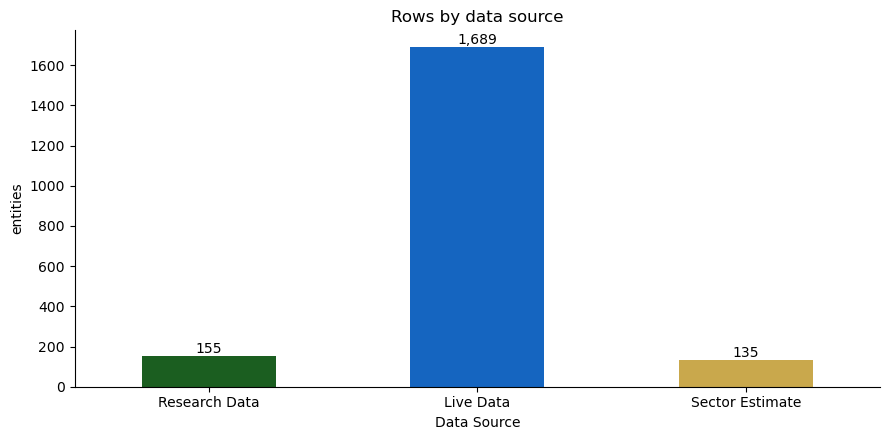

In [6]:
order = ["Research Data", "Live Data", "Sector Estimate"]
src_counts = df["Data Source"].value_counts().reindex(order).fillna(0).astype(int)
print(src_counts.to_string())

colors = {"Research Data": GREEN, "Live Data": BLUE, "Sector Estimate": GOLD}
ax = src_counts.plot.bar(color=[colors[s] for s in src_counts.index])
ax.set_title("Rows by data source"); ax.set_ylabel("entities")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(src_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 5 · Sector composition

How the listed market breaks down across the 11 GICS sectors (entity count, not market weight).

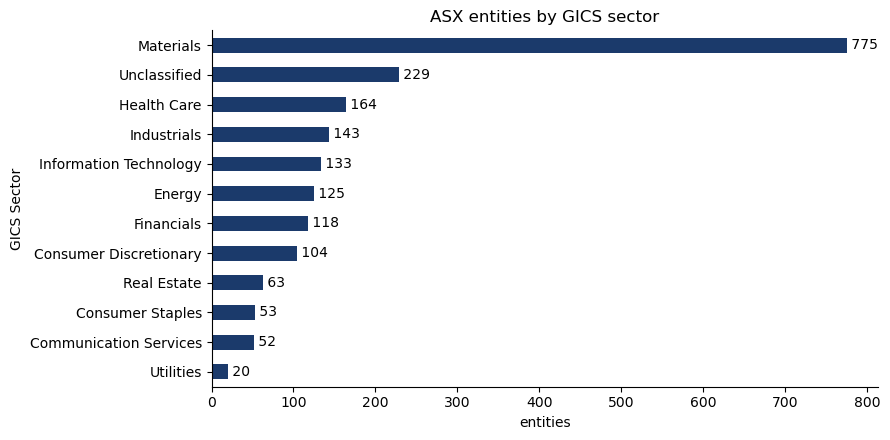

In [7]:
sector_counts = df["GICS Sector"].value_counts()
ax = sector_counts.sort_values().plot.barh(color=NAVY)
ax.set_title("ASX entities by GICS sector"); ax.set_xlabel("entities")
for i, v in enumerate(sector_counts.sort_values()):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); plt.show()

## 6 · Market-cap distribution

The classic shape of a listed market: a few mega-caps and a very long micro/nano-cap tail.

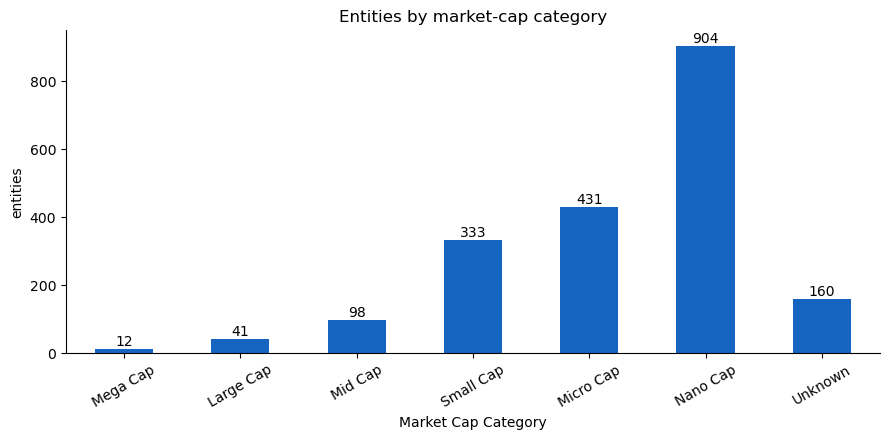

In [8]:
cap_order = ["Mega Cap", "Large Cap", "Mid Cap", "Small Cap", "Micro Cap", "Nano Cap", "Unknown"]
cap_counts = df["Market Cap Category"].value_counts().reindex(cap_order).dropna().astype(int)
ax = cap_counts.plot.bar(color=BLUE)
ax.set_title("Entities by market-cap category"); ax.set_ylabel("entities")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(cap_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 7 · Index membership

Counts of constituents flagged for each S&P/ASX benchmark (the sets are nested: ASX 20 ⊂ 50 ⊂ 100 ⊂ 200 ⊂ All Ords).

In [9]:
idx_cols = ["ASX 20", "ASX 50", "ASX 100", "ASX 200", "All Ordinaries"]
idx_counts = pd.Series({c: int((df[c] == "Yes").sum()) for c in idx_cols})
idx_counts

ASX 20             20
ASX 50             49
ASX 100            93
ASX 200           153
All Ordinaries    282
dtype: int64

## 8 · The largest companies

Sorting on market cap is trivial once everything is in one tidy frame. We parse the formatted `Market Cap (AUD)` strings back to numbers for analysis.

In [10]:
def parse_num(s):
    m = re.search(r"-?[\d.]+", str(s))
    return float(m.group()) if m else None

df["_mc_b"] = df["Market Cap (AUD)"].map(parse_num)   # A$289.200B -> 289.2
df["_dy"] = df["Dividend Yield"].map(parse_num)        # 3.8% -> 3.8

top = df.nlargest(15, "_mc_b")[
    ["Company", "ASX Ticker", "GICS Sector", "Market Cap (AUD)",
     "Share Price (AUD)", "P/E Ratio", "Dividend Yield", "Data Source"]
]
top.reset_index(drop=True)

,Company,ASX Ticker,GICS Sector,Market Cap (AUD),Share Price (AUD),P/E Ratio,Dividend Yield,Data Source
0,COMMONWEALTH BANK OF AUSTRALIA,CBA,Financials,A$289.200B,A$172.8000,22.5x,3.8%,Research Data
1,BHP GROUP LIMITED,BHP,Materials,A$260.300B,A$51.2300,14.2x,4.2%,Research Data
2,NEWMONT CORPORATION,NEM,Materials,A$157.112B,A$147.1700,13.4x,0.7%,Live Data
3,WESTPAC BANKING CORPORATION,WBC,Financials,A$136.300B,A$39.8500,16.5x,5.1%,Research Data
4,NATIONAL AUSTRALIA BANK LIMITED,NAB,Financials,A$128.200B,A$41.8000,17.2x,4.8%,Research Data
5,ANZ GROUP HOLDINGS LIMITED,ANZ,Financials,A$110.400B,A$36.6300,15.8x,5.5%,Research Data
6,WESFARMERS LIMITED,WES,Consumer Discretionary,A$83.200B,A$73.3400,35.0x,2.9%,Research Data
7,MACQUARIE GROUP LIMITED,MQG,Financials,A$78.400B,A$205.5900,22.1x,2.8%,Research Data
8,CSL LIMITED,CSL,Health Care,A$67.400B,A$138.9300,30.5x,1.4%,Research Data
9,TELSTRA GROUP LIMITED,TLS,Communication Services,A$60.900B,A$5.4200,22.0x,4.1%,Research Data


## 9 · A worked screen

Because every metric lives in one frame, screening is a one-liner. Here: **ASX 200 materials companies yielding more than 4%**, sorted by market cap — a typical income-tilted resources screen.

In [11]:
screen = df[(df["ASX 200"] == "Yes") & (df["GICS Sector"] == "Materials") & (df["_dy"] > 4)]
screen = screen.sort_values("_mc_b", ascending=False)
print(f"{len(screen)} companies match the screen")
screen[["Company", "ASX Ticker", "Market Cap (AUD)", "Dividend Yield",
        "P/E Ratio", "Data Source"]].reset_index(drop=True)

4 companies match the screen


,Company,ASX Ticker,Market Cap (AUD),Dividend Yield,P/E Ratio,Data Source
0,BHP GROUP LIMITED,BHP,A$260.300B,4.2%,14.2x,Research Data
1,RIO TINTO LIMITED,RIO,A$60.100B,5.8%,11.0x,Research Data
2,FORTESCUE LTD,FMG,A$24.500B,5.5%,12.5x,Research Data
3,DETERRA ROYALTIES LIMITED,DRR,A$3.800B,5.0%,18.0x,Research Data


## 10 · The full depth of gathered data

The workbook keeps a curated 44 columns, but the live cache holds much more per ticker — 52-week range, analyst consensus and price targets, liquidity. Here is the analyst-coverage view for live-sourced names.

In [12]:
rows = []
for t, d in cache.items():
    if d.get("numberOfAnalystOpinions"):
        rows.append({
            "Ticker": t,
            "Name": d.get("longName") or d.get("shortName"),
            "Price": d.get("currentPrice"),
            "52w Low": d.get("fiftyTwoWeekLow"),
            "52w High": d.get("fiftyTwoWeekHigh"),
            "Analysts": d.get("numberOfAnalystOpinions"),
            "Consensus": d.get("recommendationKey"),
            "Mean Target": d.get("targetMeanPrice"),
        })
analyst = pd.DataFrame(rows).sort_values("Analysts", ascending=False)
print(f"{len(analyst):,} tickers carry analyst coverage in the live snapshot")
analyst.head(15).reset_index(drop=True)

730 tickers carry analyst coverage in the live snapshot


,Ticker,Name,Price,52w Low,52w High,Analysts,Consensus,Mean Target
0,HUB,HUB24 Limited,82.920,74.920,122.030,17,buy,100.736470
1,PLS,PLS Group Limited,6.555,1.180,6.810,17,hold,5.641180
2,SDR,SiteMinder Limited,4.105,2.600,7.960,17,strong_buy,6.031760
3,LNW,"Light & Wonder, Inc.",129.570,96.790,193.000,17,strong_buy,174.883870
4,JHX,James Hardie Industries plc,35.015,24.410,45.980,17,buy,34.949860
5,BHP,BHP Group Limited,64.950,35.520,65.440,17,hold,57.327354
6,FMG,Fortescue Ltd,20.635,14.310,23.380,17,hold,19.092123
7,EVN,Evolution Mining Limited,12.790,6.960,17.750,17,buy,13.885290
8,ALL,Aristocrat Leisure Limited,53.250,44.180,73.290,17,strong_buy,63.040590
9,COL,Coles Group Limited,23.240,20.100,24.280,16,buy,23.263590


## 11 · Export to Excel

Finally, `build_workbook()` renders the frame into the three-sheet, professionally formatted workbook — the deliverable a non-technical user actually opens.

In [13]:
from src.format_excel import build_workbook

out = ROOT / "output" / "ASX_Master_Database.xlsx"
out.parent.mkdir(exist_ok=True)
clean = df.drop(columns=[c for c in df.columns if c.startswith("_")])
build_workbook(df=clean, output_path=out)
print("Workbook written:", out.relative_to(ROOT), f"({out.stat().st_size/1024:.0f} KB)")

Workbook written: output\ASX_Master_Database.xlsx (564 KB)


---
### Recap

From a flat list of 1,979 tickers, the toolkit **automatically gathered live market data**, merged it with curated research and sector logic, classified every entity across four GICS tiers and five index memberships, and packaged the result into both a tidy DataFrame for analysis and a polished Excel workbook for distribution — reproducibly, from a single command.